In [16]:
!pip install mplsoccer

In [17]:
!pip install soccerplots

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mplsoccer import PyPizza, add_image, FontManager
from soccerplots.radar_chart import Radar
from scipy import stats
import math

In [19]:
df = pd.read_csv('/content/drive/MyDrive/F_Data_Academy/radars.csv')

In [20]:
df.head()

,Rk,Player,Nation,Pos,Squad,Age,Born,90s,Gls,Sh,...,Dist,FK,PK,PKatt,xG,npxG,npxG/Sh,G-xG,np:G-xG,Matches
0,1,Patrick van Aanholt\Patrick-van-Aanholt,nl NED,DF,Crystal Palace,30-185,1990,13.7,0,15,...,20.6,3,0,0,0.8,0.8,0.05,-0.8,-0.8,Matches
1,2,Tammy Abraham\Tammy-Abraham,eng ENG,FW,Chelsea,23-151,1997,11.3,6,31,...,9.9,0,0,0,5.6,5.6,0.18,0.4,0.4,Matches
2,3,Che Adams\Che-Adams,eng ENG,FW,Southampton,24-232,1996,21.2,4,40,...,13.5,0,0,0,5.3,5.3,0.13,-1.3,-1.3,Matches
3,4,Tosin Adarabioyo\Tosin-Adarabioyo,eng ENG,DF,Fulham,23-159,1997,22.0,0,17,...,9.0,0,0,0,0.9,0.9,0.06,-0.9,-0.9,Matches
4,5,Adrián\Adrian,es ESP,GK,Liverpool,34-058,1987,3.0,0,0,...,NaN,0,0,0,0.0,0.0,NaN,0.0,0.0,Matches


In [21]:
df['Player'] = df ['Player'].str.split('\\',expand=True)[0]

In [22]:
df.Player.unique()

array(['Patrick van Aanholt', 'Tammy Abraham', 'Che Adams',
       'Tosin Adarabioyo', 'Adrián', 'Sergio Agüero', 'Ola Aina',
       'Rayan Aït Nouri', 'Semi Ajayi', 'Nathan Aké', 'Marc Albrighton',
       'Thiago Alcántara', 'Toby Alderweireld', 'Rúnar Alex Rúnarsson',
       'Trent Alexander-Arnold', 'Ezgjan Alioski', 'Alisson', 'Allan',
       'Dele Alli', 'Miguel Almirón', 'Marcos Alonso', 'Steven Alzate',
       'Daniel Amartey', 'Ethan Ampadu', 'Joachim Andersen',
       'Elliot Anderson', 'Felipe Anderson', 'Michail Antonio',
       'Alphonse Areola', 'Stuart Armstrong', 'Kepa Arrizabalaga',
       'Pierre-Emerick Aubameyang', 'Serge Aurier', 'Charlie Austin',
       'Jordan Ayew', 'Luke Ayling', 'César Azpilicueta', 'Eric Bailly',
       'Fabián Balbuena', 'George Baldock', 'Gareth Bale',
       'Patrick Bamford', 'Phil Bardsley', 'Ross Barkley',
       'Ashley Barnes', 'Harvey Barnes', 'Kyle Bartley', 'Chris Basham',
       'Michy Batshuayi', 'Jan Bednarek', 'Donny van de Beek

In [23]:
df.head()

,Rk,Player,Nation,Pos,Squad,Age,Born,90s,Gls,Sh,...,Dist,FK,PK,PKatt,xG,npxG,npxG/Sh,G-xG,np:G-xG,Matches
0,1,Patrick van Aanholt,nl NED,DF,Crystal Palace,30-185,1990,13.7,0,15,...,20.6,3,0,0,0.8,0.8,0.05,-0.8,-0.8,Matches
1,2,Tammy Abraham,eng ENG,FW,Chelsea,23-151,1997,11.3,6,31,...,9.9,0,0,0,5.6,5.6,0.18,0.4,0.4,Matches
2,3,Che Adams,eng ENG,FW,Southampton,24-232,1996,21.2,4,40,...,13.5,0,0,0,5.3,5.3,0.13,-1.3,-1.3,Matches
3,4,Tosin Adarabioyo,eng ENG,DF,Fulham,23-159,1997,22.0,0,17,...,9.0,0,0,0,0.9,0.9,0.06,-0.9,-0.9,Matches
4,5,Adrián,es ESP,GK,Liverpool,34-058,1987,3.0,0,0,...,NaN,0,0,0,0.0,0.0,NaN,0.0,0.0,Matches


In [24]:
df = df[(df['Player']=='Nicolas Pépé') | (df['Player']=='Ferrán Torres')].reset_index()

In [25]:
df

,index,Rk,Player,Nation,Pos,Squad,Age,Born,90s,Gls,...,Dist,FK,PK,PKatt,xG,npxG,npxG/Sh,G-xG,np:G-xG,Matches
0,348,349,Nicolas Pépé,ci CIV,FW,Arsenal,25-277,1995,10.8,5,...,16.9,1,1,1,3.9,3.1,0.10,1.1,0.9,Matches
1,450,451,Ferrán Torres,es ESP,FW,Manchester City,21-001,2000,8.9,2,...,16.0,0,0,0,2.6,2.6,0.13,-0.6,-0.6,Matches


In [26]:
df = df.drop(['index', 'Rk', 'Nation', 'Pos', 'Squad', 'Age', 'Born', '90s', 'FK', 'PK', 'PKatt', 'Matches'],axis=1)

In [27]:
df

,Player,Gls,Sh,SoT,SoT%,Sh/90,SoT/90,G/Sh,G/SoT,Dist,xG,npxG,npxG/Sh,G-xG,np:G-xG
0,Nicolas Pépé,5,30,9,30.0,2.77,0.83,0.13,0.44,16.9,3.9,3.1,0.10,1.1,0.9
1,Ferrán Torres,2,20,8,40.0,2.24,0.90,0.10,0.25,16.0,2.6,2.6,0.13,-0.6,-0.6


In [28]:
params = list(df.columns)
params = params[1:]
params

['Gls',
 'Sh',
 'SoT',
 'SoT%',
 'Sh/90',
 'SoT/90',
 'G/Sh',
 'G/SoT',
 'Dist',
 'xG',
 'npxG',
 'npxG/Sh',
 'G-xG',
 'np:G-xG']

In [29]:
ranges = []
a_values = []
b_values = []

for x in params:
  a = min(df[params][x])
  a = a - (a*.25)

  b = max(df[params][x])
  b = b + (b*.25)

  ranges.append((a,b))

for x in range(len(df['Player'])):
  if df['Player'][x] == 'Nicolas Pépé':
    a_values = df.iloc[x].values.tolist()
  if df['Player'][x] == 'Ferrán Torres':
    b_values = df.iloc[x].values.tolist()

a_values = a_values[1:]
b_values = b_values[1:]

values = [a_values,b_values]

In [31]:
values_limpios = [[float(x) if isinstance(x, (np.float64, float)) else int(x) for x in jugador] for jugador in values]

# Imprime el resultado para verificar
print(values_limpios)

[[5, 30, 9, 30.0, 2.77, 0.83, 0.13, 0.44, 16.9, 3.9, 3.1, 0.1, 1.1, 0.9], [2, 20, 8, 40.0, 2.24, 0.9, 0.1, 0.25, 16.0, 2.6, 2.6, 0.13, -0.6, -0.6]]


In [33]:
title = dict(
    title_name ='Nicolas Pépé',
    title_color ='red',
    subtitle_name = 'Arsenal',
    subtitle_color = 'red',
    title_name_2 ='Ferrán Torres',
    title_color_2 ='blue',
    subtitle_name_2 = 'Manchester City',
    subtitle_color_2 = 'blue',
    title_fontsize = 18,
    subtitle_fontsize = 15
)

endnote = '@futboldata_academy'

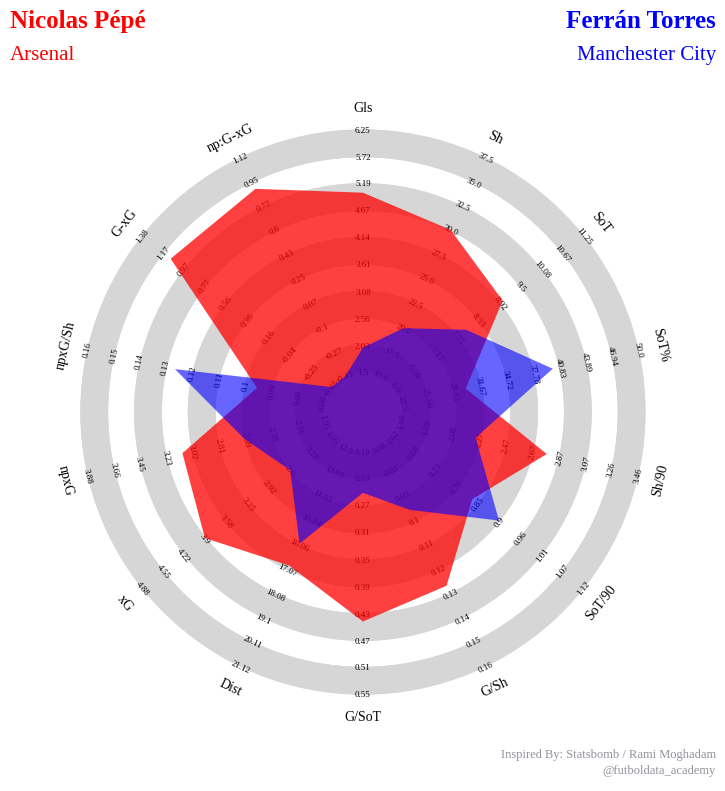

In [34]:
radar = Radar()

fig,ax = radar.plot_radar(ranges=ranges,params=params,values=values,
                          radar_color=['red','blue'],
                          alphas=[.75,.6], title=title,endnote=endnote,
                          compare=True)